<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/OTProcessNetworkDataFusion_Version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Background:

This notebook demonstrates the **fusion of network anomaly scores and process classification results** for cyber-physical threat detection, with the goal of assessing the **generalization capability** of detection models across:
  - **Seen data** (instances 1 – 50): normal and single-vector attack behaviors
  - **Unseen data** (instances 51 – 60): multi-vector, stealthy attack scenarios

The datasets provides a side-by-side comparison of the anomaly socres for all 60 instances:
  - **Network-only detection** using Isolation Forest
  - **Process-only detection** using LSTM-FCN Time Series Classifier
  - **Fusion detection** using combined logic

The results show that **fusion improves detection performance (accuracy, F1 Score)**, especially in identifying **unseen and stealthy multi-vector Advanced Persistent Threat (APT)** behaviors (instance 51 - 60).




# Step 1: Loading the process data and network data


## Network Data

In [1]:
# Step 1: network data and process data
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Load Network Data with Anomaly Scores calculated by Isolation Forest
df_network = pd.read_csv("instance_anomaly_summary.csv")


Saving instance_anomaly_summary.csv to instance_anomaly_summary.csv


In [2]:
# Rename columns and reassign
df_network = df_network.rename(columns={
    'anomaly_0.25': 'Network_Predicted_Label', # when anomaly_score_0.25 has a positive value, it is normal. otherwise, negative value denotes anomalous case
    'label': 'Network_Ground_Truth'
})

df_network['Network_Predicted_Label'] = df_network['anomaly_score_0.25'].apply(lambda x: 1 if x < 0 else 0)
df_network['instance'] = df_network['instance'].astype(int)

In [3]:
df_network

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,anomaly_score_0.25,Network_Predicted_Label,Network_Ground_Truth
0,1,0,0.000000,584,0.234256,2493,0.115396,0,0
1,2,0,0.000000,514,0.233424,2202,-0.076033,1,0
2,3,0,0.000000,583,0.234231,2489,0.146823,0,0
3,4,0,0.000000,572,0.234234,2442,0.148887,0,0
4,5,0,0.000000,540,0.234070,2307,0.152311,0,0
5,6,0,0.000000,590,0.234406,2517,-0.007075,1,0
6,7,0,0.000000,569,0.233868,2433,0.021224,0,0
7,8,0,0.000000,584,0.234068,2495,0.154344,0,0
8,9,0,0.000000,576,0.230124,2503,-0.282645,1,0
9,10,0,0.000000,576,0.234051,2461,0.128183,0,0


In [4]:
def interpret_anomaly(score):
    if score < -0.05:
        return 'Network - Anomaly'
    elif score > 0.05:
        return 'Network - Normal'
    else:
        return 'Network - Marginal'

df_network['Network_Label_3Class'] = df_network['anomaly_score_0.25'].apply(interpret_anomaly)

In [5]:
df_network

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,anomaly_score_0.25,Network_Predicted_Label,Network_Ground_Truth,Network_Label_3Class
0,1,0,0.000000,584,0.234256,2493,0.115396,0,0,Network - Normal
1,2,0,0.000000,514,0.233424,2202,-0.076033,1,0,Network - Anomaly
2,3,0,0.000000,583,0.234231,2489,0.146823,0,0,Network - Normal
3,4,0,0.000000,572,0.234234,2442,0.148887,0,0,Network - Normal
4,5,0,0.000000,540,0.234070,2307,0.152311,0,0,Network - Normal
5,6,0,0.000000,590,0.234406,2517,-0.007075,1,0,Network - Marginal
6,7,0,0.000000,569,0.233868,2433,0.021224,0,0,Network - Marginal
7,8,0,0.000000,584,0.234068,2495,0.154344,0,0,Network - Normal
8,9,0,0.000000,576,0.230124,2503,-0.282645,1,0,Network - Anomaly
9,10,0,0.000000,576,0.234051,2461,0.128183,0,0,Network - Normal


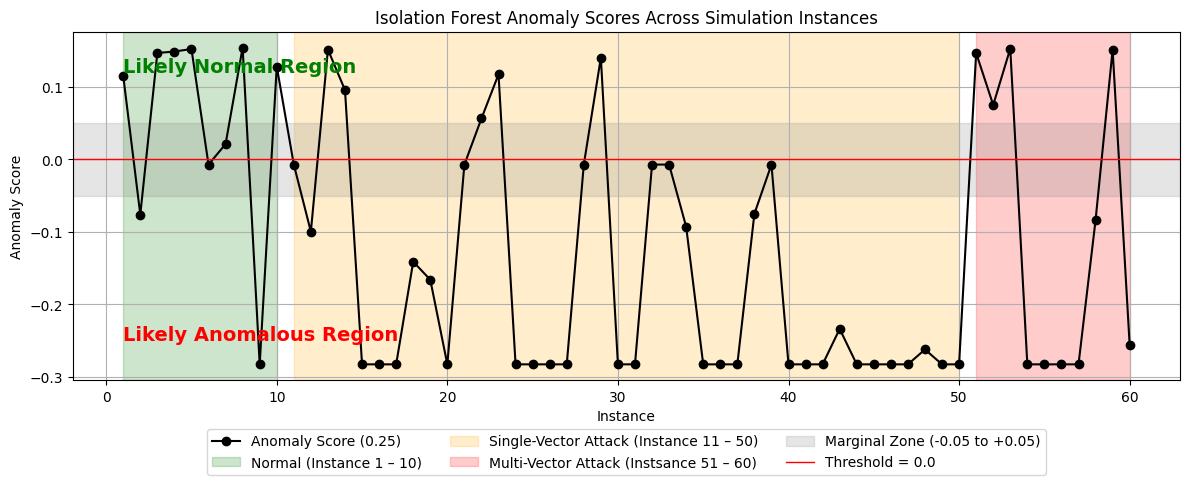

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot anomaly scores across all 60 instances
plt.figure(figsize=(12, 5))
plt.plot(df_network['instance'], df_network['anomaly_score_0.25'], marker='o', linestyle='-', color='black', label='Anomaly Score (0.25)')

# Highlight the regions
plt.axvspan(1, 10, color='green', alpha=0.2, label='Normal (Instance 1 – 10)')
plt.axvspan(11, 50, color='orange', alpha=0.2, label='Single-Vector Attack (Instance 11 – 50)')
plt.axvspan(51, 60, color='red', alpha=0.2, label='Multi-Vector Attack (Instsance 51 – 60)')
plt.axhspan(-0.05, 0.05, color='gray', alpha=0.2, label='Marginal Zone (-0.05 to +0.05)')
plt.axhline(y=0.0, color='red', linestyle='-', linewidth=1, label='Threshold = 0.0')
plt.text(1, 0.12, 'Likely Normal Region', color='green', fontsize=14, weight='bold')
plt.text(1, -0.25, 'Likely Anomalous Region', color='red', fontsize=14, weight='bold')

plt.title("Isolation Forest Anomaly Scores Across Simulation Instances")
plt.xlabel("Instance")
plt.ylabel("Anomaly Score")
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.show()

In [6]:
# Count occurrences of each class
df_network['Network_Label_3Class'].value_counts()


,count
Network_Label_3Class,
Network - Anomaly,37
Network - Normal,15
Network - Marginal,8


In [7]:
df_network['Network_Label_3Class'].value_counts(normalize=True) * 100

,proportion
Network_Label_3Class,
Network - Anomaly,61.666667
Network - Normal,25.000000
Network - Marginal,13.333333


In [19]:
# Filter marginal cases
n_marginal_cases = df_network[df_network['Network_Label_3Class'] == 'Network - Marginal']

# Get instance numbers (assuming 'instance' column exists)
n_marginal_instance_numbers = marginal_cases['instance'].tolist()

# Show result
print("Network Marginal Instances:", n_marginal_instance_numbers)

Network Marginal Instances: [6, 7, 11, 21, 28, 32, 33, 39]


**From the network-only detection results, 8 out of 60 instances (13.3%) fell into a marginal zone, where the anomaly score is near zero. These ambiguous cases could not be confidently classified as either normal or anomalous. This justifies the integration of process-level data for decision fusion, as it provides complementary context to resolve uncertainty in marginal instances.**

## Process Data

In [10]:
uploaded = files.upload()

# Load Process Data with Class Scores calculated by LSTM-FCN
df_process = pd.read_csv("NX_process_predictions_all60_with_label.csv")


Saving NX_process_predictions_all60_with_label.csv to NX_process_predictions_all60_with_label.csv


In [11]:
# Rename columns and reassign
df_process = df_process.rename(columns={
    'Instance': 'instance',
    'Predicted_Label': 'Process_Predicted_Label',  # the predicted label is the class that achieved the highest percentage
    'Ground Truth': 'Process_Ground_Truth'
})

df_process['instance'] = df_process['instance'].astype(int)

# Convert probability percentage strings to float values (e.g., "99.99%" → 0.9999)
prob_cols = ['Prob_Class_0', 'Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']
for col in prob_cols:
    df_process[col] = df_process[col].str.rstrip('%').astype(float) / 100.0

In [12]:
df_process

,instance,Process_Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Process_Ground_Truth,Label_Description
0,1,0,0.9999,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention
1,2,0,0.9999,0.0000,0.0001,0.0000,0.0000,0,Label 0: Normal_NoIntervention
2,3,0,0.9998,0.0000,0.0001,0.0000,0.0001,0,Label 0: Normal_NoIntervention
3,4,2,0.0061,0.0003,0.9923,0.0002,0.0011,0,Label 0: Normal_NoIntervention
4,5,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention
5,6,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention
6,7,0,0.9999,0.0000,0.0001,0.0000,0.0000,0,Label 0: Normal_NoIntervention
7,8,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention
8,9,0,0.9996,0.0000,0.0002,0.0000,0.0001,0,Label 0: Normal_NoIntervention
9,10,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention


We define the process score achieved the following values as high confidence:



*   Normal cases: probability value 0 - 0.2
*   Threat cases: probability value 0.8 - 1



In [13]:
# Find the maximum probability of the threat classes
df_process['process_score'] = df_process[['Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']].max(axis=1)

# Apply 3-class label logic
def classify_process(score):
    if score <= 0.20:
        return 'Process - Normal'
    elif score >= 0.80:
        return 'Process - Anomaly'
    else:
        return 'Process - Marginal'

df_process['Process_Label_3Class'] = df_process['process_score'].apply(classify_process)

In [70]:
# Check the correctness of the process score for normal class (Prob_Class_0)
df_process[['Prob_Class_0', 'process_score']].head(10)

,Prob_Class_0,process_score
0,0.9999,0.0000
1,0.9999,0.0001
2,0.9998,0.0001
3,0.0061,0.9923
4,1.0000,0.0000
5,1.0000,0.0000
6,0.9999,0.0001
7,1.0000,0.0000
8,0.9996,0.0002
9,1.0000,0.0000


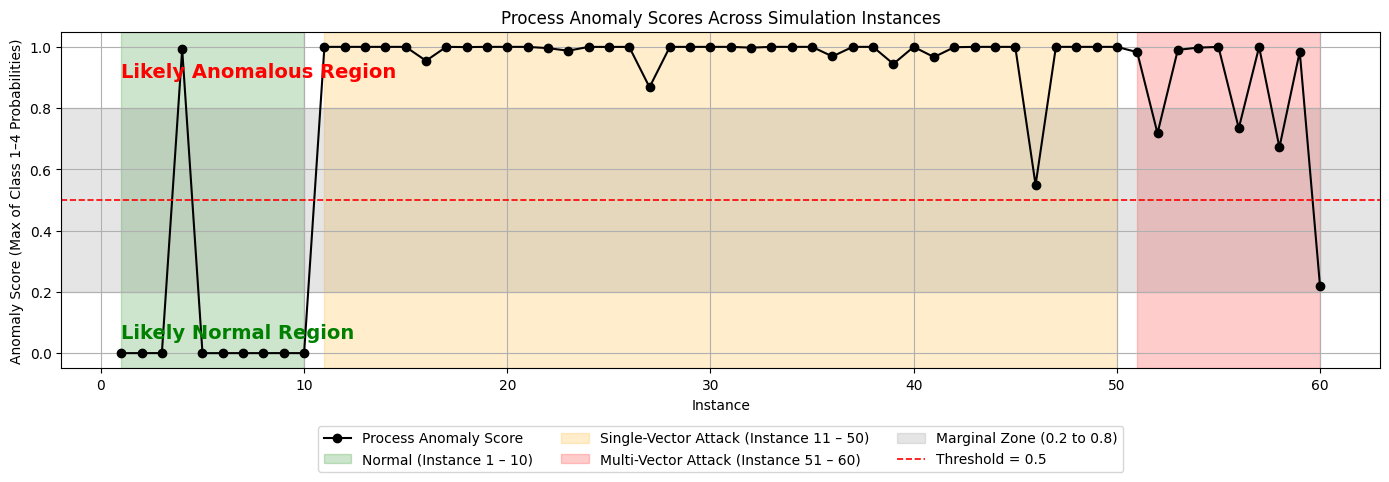

In [14]:
import matplotlib.pyplot as plt

# Set up the figure
plt.figure(figsize=(14, 5))

# Plot the process anomaly score (max of Prob_Class_1–4)
plt.plot(df_process['instance'], df_process['process_score'], marker='o', linestyle='-', color='black', label='Process Anomaly Score')

# Highlight background by instance ranges
plt.axvspan(1, 10, color='green', alpha=0.2, label='Normal (Instance 1 – 10)')
plt.axvspan(11, 50, color='orange', alpha=0.2, label='Single-Vector Attack (Instance 11 – 50)')
plt.axvspan(51, 60, color='red', alpha=0.2, label='Multi-Vector Attack (Instance 51 – 60)')

# Highlight marginal zone based on threshold
plt.axhspan(0.2, 0.8, color='gray', alpha=0.2, label='Marginal Zone (0.2 to 0.8)')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.2, label='Threshold = 0.5')

# Annotate normal and anomalous regions
plt.text(1, 0.9, 'Likely Anomalous Region', color='red', fontsize=14, weight='bold')
plt.text(1, 0.05, 'Likely Normal Region', color='green', fontsize=14, weight='bold')

# Plot title and labels
plt.title("Process Anomaly Scores Across Simulation Instances")
plt.xlabel("Instance")
plt.ylabel("Anomaly Score (Max of Class 1–4 Probabilities)")
plt.grid(True)

# Legend placement
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.show()

In [15]:
df_process['Process_Label_3Class'].value_counts()

,count
Process_Label_3Class,
Process - Anomaly,46
Process - Normal,9
Process - Marginal,5


In [16]:
df_process['Process_Label_3Class'].value_counts(normalize=True) * 100

,proportion
Process_Label_3Class,
Process - Anomaly,76.666667
Process - Normal,15.000000
Process - Marginal,8.333333


In [20]:
# Filter marginal cases
p_marginal_cases = df_process[df_process['Process_Label_3Class'] == 'Process - Marginal']

# Get instance numbers (assuming 'instance' column exists)
p_marginal_instance_numbers = p_marginal_cases['instance'].tolist()

# Show result
print("Process Marginal Instances:", p_marginal_instance_numbers)

Process Marginal Instances: [46, 52, 56, 58, 60]


**From the process-only detection results, 5 out of 60 instances (8.3%) fell into a marginal zone. These ambiguous cases could not be confidently classified as either normal or anomalous. This justifies the integration of network-level data for decision fusion, as it provides complementary context to resolve uncertainty in marginal instances.**

# Step 2 Merge and normalize

## Merging Process Data and Network Data

In [21]:
# Ensure both DataFrames have the same column name for merging
df_process = df_process.rename(columns={'Instance': 'instance'})
df_process['instance'] = df_process['instance'].astype(int)
df_network['instance'] = df_network['instance'].astype(int)

# Now perform the merge correctly
df_combined = pd.merge(
    df_network,              # left DataFrame
    df_process,              # right DataFrame
    on='instance',           # common column to merge on
    how='inner'              # merge type (inner keeps only matching instances)
)

# Display the result
df_combined

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,anomaly_score_0.25,Network_Predicted_Label,Network_Ground_Truth,Network_Label_3Class,Process_Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Process_Ground_Truth,Label_Description,process_score,Process_Label_3Class
0,1,0,0.000000,584,0.234256,2493,0.115396,0,0,Network - Normal,0,0.9999,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal
1,2,0,0.000000,514,0.233424,2202,-0.076033,1,0,Network - Anomaly,0,0.9999,0.0000,0.0001,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0001,Process - Normal
2,3,0,0.000000,583,0.234231,2489,0.146823,0,0,Network - Normal,0,0.9998,0.0000,0.0001,0.0000,0.0001,0,Label 0: Normal_NoIntervention,0.0001,Process - Normal
3,4,0,0.000000,572,0.234234,2442,0.148887,0,0,Network - Normal,2,0.0061,0.0003,0.9923,0.0002,0.0011,0,Label 0: Normal_NoIntervention,0.9923,Process - Anomaly
4,5,0,0.000000,540,0.234070,2307,0.152311,0,0,Network - Normal,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal
5,6,0,0.000000,590,0.234406,2517,-0.007075,1,0,Network - Marginal,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal
6,7,0,0.000000,569,0.233868,2433,0.021224,0,0,Network - Marginal,0,0.9999,0.0000,0.0001,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0001,Process - Normal
7,8,0,0.000000,584,0.234068,2495,0.154344,0,0,Network - Normal,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal
8,9,0,0.000000,576,0.230124,2503,-0.282645,1,0,Network - Anomaly,0,0.9996,0.0000,0.0002,0.0000,0.0001,0,Label 0: Normal_NoIntervention,0.0002,Process - Normal
9,10,0,0.000000,576,0.234051,2461,0.128183,0,0,Network - Normal,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal


In [22]:
df_combined.to_csv('combined_network_process_view.csv', index=False)

from google.colab import files
files.download('combined_network_process_view.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Rule-based Confidence-Aware Decision Fusion

**Why decision fusion?**

From the analysis above, the marginal cases include

1.   Network Marginal Instances: [6, 7, 11, 21, 28, 32, 33, 39]
2.   Process Marginal Instances: [46, 52, 56, 58, 60]

The purpose of the decision fusion is to handle the marginal instances. If the overall result align (i.e., network score and process score indicate normal), we use the label of process score for explainability. If the overall result contradict (i.e., network score says normal, process score says threat, we compare the absolute value of the two score to see who has higher score.


**Logic behind:**

A process model that gives multiclass predictions: Label 0 - 4 (Normal, then types of attack).

A network score from Isolation Forest, where:

*   network_score > 0: Normal
*   network_score < 0: Anomalous

But network_score does not tell us which type of attack.

If process confidence is low (process score is less than 0.8), and network score is anomalous (and wins by absolute confidence), then pick the most likely attack class from the process model — since network model does not distinguish attack types. This retains the fine-grained attack classification from process model.

In [71]:
!pip install graphviz

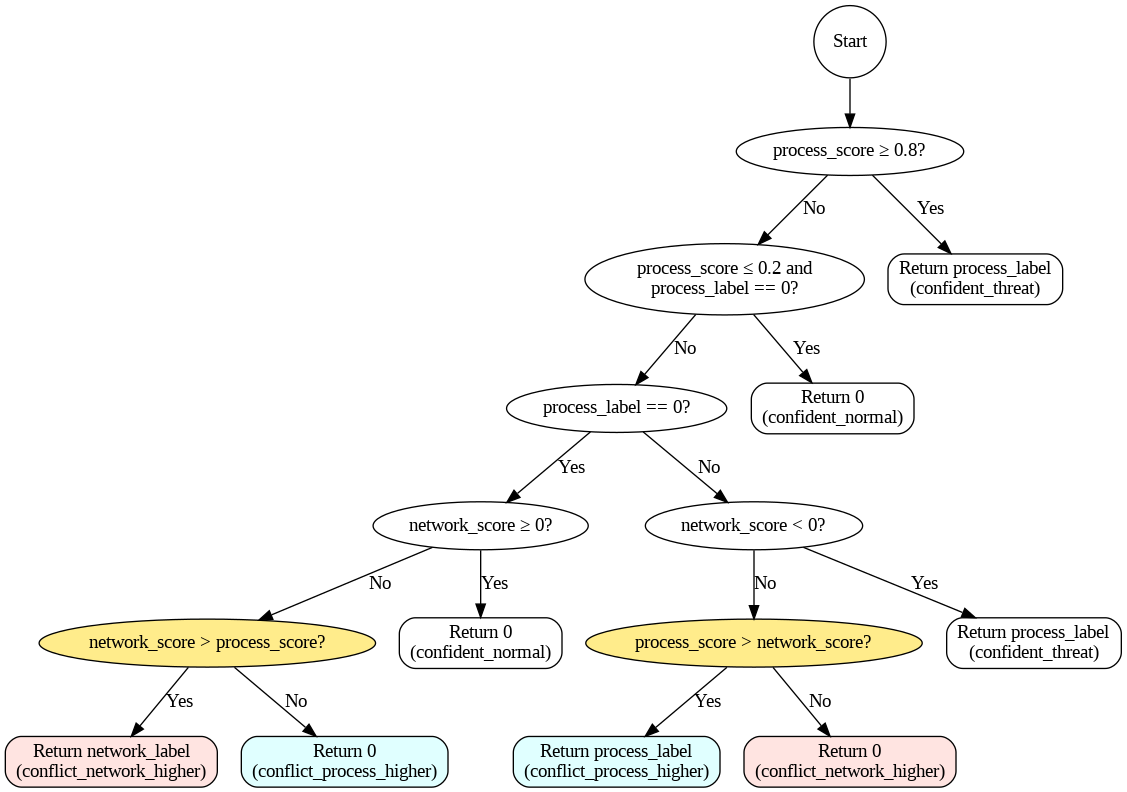

In [78]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph(comment='Rule-based Confidence-Aware Decision Fusion')

# Styles for special cases
marginal_style = {'style': 'filled', 'fillcolor': 'lightgoldenrod1'}

# Decision Nodes
dot.node('A', 'Start', shape='circle')
dot.node('B', 'process_score ≥ 0.8?', shape='ellipse')
dot.node('D', 'process_score ≤ 0.2 and\nprocess_label == 0?', shape='ellipse')
dot.node('F', 'process_label == 0?', shape='ellipse')
dot.node('G', 'network_score ≥ 0?', shape='ellipse')
dot.node('I', 'network_score > process_score?', shape='ellipse', **marginal_style)
dot.node('L', 'network_score < 0?', shape='ellipse')
dot.node('N', 'process_score > network_score?', shape='ellipse', **marginal_style)

# Leaf/Output Nodes
dot.node('C', 'Return process_label\n(confident_threat)', shape='box', style='rounded')
dot.node('E', 'Return 0\n(confident_normal)', shape='box', style='rounded')
dot.node('H', 'Return 0\n(confident_normal)', shape='box', style='rounded')
dot.node('J', 'Return network_label\n(conflict_network_higher)', shape='box', style='rounded,filled', fillcolor='mistyrose')
dot.node('K', 'Return 0\n(conflict_process_higher)', shape='box', style='rounded,filled', fillcolor='lightcyan')
dot.node('O', 'Return process_label\n(conflict_process_higher)', shape='box', style='rounded,filled', fillcolor='lightcyan')
dot.node('P', 'Return 0\n(conflict_network_higher)', shape='box', style='rounded,filled', fillcolor='mistyrose')
dot.node('M', 'Return process_label\n(confident_threat)', shape='box', style='rounded')

# Arrows / Decision Paths
dot.edge('A', 'B')
dot.edge('B', 'C', 'Yes')
dot.edge('B', 'D', 'No')
dot.edge('D', 'E', 'Yes')
dot.edge('D', 'F', 'No')
dot.edge('F', 'G', 'Yes')
dot.edge('G', 'H', 'Yes')
dot.edge('G', 'I', 'No')
dot.edge('I', 'J', 'Yes')
dot.edge('I', 'K', 'No')
dot.edge('F', 'L', 'No')
dot.edge('L', 'M', 'Yes')
dot.edge('L', 'N', 'No')
dot.edge('N', 'O', 'Yes')
dot.edge('N', 'P', 'No')

# Save and display
dot.render('fusion_confidence_tree_marginal', format='png', cleanup=True)
Image(filename='fusion_confidence_tree_marginal.png')

In [53]:
def resolve_final_label_with_reason(row):
    process_score = row['process_score']  # 0.0 to 1.0
    network_score = row['anomaly_score_0.25']  # +ve = Normal, -ve = Anomaly
    process_label = row['Process_Predicted_Label']  # 0 = Normal, 1–4 = Attack class

    try:
        attack_classes = ['Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']
        attack_scores = row[attack_classes].astype(float)
    except Exception as e:
        return pd.Series([process_label, 'error_attack_score'])

    # Step 1: Convert network anomaly score into a label
    if network_score >= 0:
        network_label = 0
    else:
        best_attack_class = attack_scores.idxmax()
        network_label = int(best_attack_class.split('_')[-1])

    # Step 2: High confidence regions for process (trust process label directly)
    if process_score >= 0.8:
        return pd.Series([process_label, 'confident_threat'])

    if process_score <= 0.2 and process_label == 0:
        return pd.Series([0, 'confident_normal'])

    # Step 3: Marginal region for process (0.2 < score < 0.8)
    if process_label == 0: # process predicts normal
        if network_score >= 0: # network predicts normal
            return pd.Series([0, 'confident_normal'])
        else:
            final_label = network_label if abs(network_score) > process_score else 0
            return pd.Series([
                final_label,
                'conflict_network_higher' if abs(network_score) > process_score else 'conflict_process_higher'
            ])
    else: # process predicts threat
        if network_score < 0: # network predicts threat
            return pd.Series([process_label, 'confident_threat'])
        else:
            final_label = process_label if process_score > abs(network_score) else 0
            return pd.Series([
                final_label,
                'conflict_process_higher' if process_score >= abs(network_score) else 'conflict_network_higher'
            ])

In [54]:
df_combined[['final_fused_label', 'decision_reason']] = df_combined.apply(resolve_final_label_with_reason, axis=1)

In [55]:
# Evaluate against Ground Truth (fused_pred binary: 0 = normal, 1 = attack or anomaly)
df_combined[['instance', 'process_score', 'anomaly_score_0.25', 'Process_Predicted_Label', 'Network_Predicted_Label', 'final_fused_label' ,'Process_Ground_Truth', 'decision_reason']]

,instance,process_score,anomaly_score_0.25,Process_Predicted_Label,Network_Predicted_Label,final_fused_label,Process_Ground_Truth,decision_reason
0,1,0.0000,0.115396,0,0,0,0,confident_normal
1,2,0.0001,-0.076033,0,1,0,0,confident_normal
2,3,0.0001,0.146823,0,0,0,0,confident_normal
3,4,0.9923,0.148887,2,0,2,0,confident_threat
4,5,0.0000,0.152311,0,0,0,0,confident_normal
5,6,0.0000,-0.007075,0,1,0,0,confident_normal
6,7,0.0001,0.021224,0,0,0,0,confident_normal
7,8,0.0000,0.154344,0,0,0,0,confident_normal
8,9,0.0002,-0.282645,0,1,0,0,confident_normal
9,10,0.0000,0.128183,0,0,0,0,confident_normal


In [89]:
# Get the count dictionary
reasons = df_combined['decision_reason'].value_counts().to_dict()

# Extract counts safely (default to 0 if key is missing)
n_confident_threat = reasons.get('confident_threat', 0)
n_confident_normal = reasons.get('confident_normal', 0)
n_conflict_process_higher = reasons.get('conflict_process_higher', 0)
n_conflict_network_higher = reasons.get('conflict_network_higher', 0)
n_error = reasons.get('error_attack_score', 0)  # Optional, in case you want to track errors

# Print all values (optional, for debugging)
print("confident_threat:", n_confident_threat)
print("confident_normal:", n_confident_normal)
print("conflict_process_higher:", n_conflict_process_higher)
print("conflict_network_higher:", n_conflict_network_higher)

confident_threat: 49
confident_normal: 9
conflict_process_higher: 1
conflict_network_higher: 1


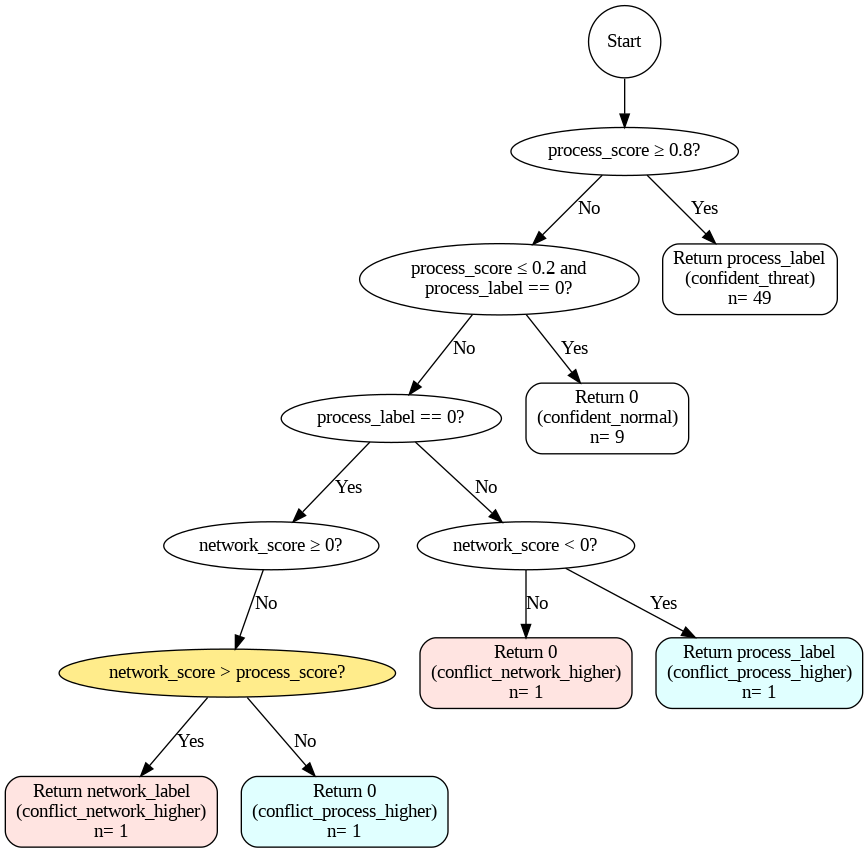

In [91]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph(comment='Rule-based Confidence-Aware Decision Fusion')

# Styles for special cases
marginal_style = {'style': 'filled', 'fillcolor': 'lightgoldenrod1'}

# Decision Nodes
dot.node('A', 'Start', shape='circle')
dot.node('B', 'process_score ≥ 0.8?', shape='ellipse')
dot.node('D', 'process_score ≤ 0.2 and\nprocess_label == 0?', shape='ellipse')
dot.node('F', 'process_label == 0?', shape='ellipse')
dot.node('G', 'network_score ≥ 0?', shape='ellipse')
dot.node('I', 'network_score > process_score?', shape='ellipse', **marginal_style)
dot.node('L', 'network_score < 0?', shape='ellipse')
dot.node('N', 'process_score > network_score?', shape='ellipse', **marginal_style)

# Leaf/Output Nodes
dot.node('C', f'Return process_label\n(confident_threat)\nn= {reasons.get("confident_threat", 0)}', shape='box', style='rounded')
dot.node('E', f'Return 0\n(confident_normal)\nn= {reasons.get("confident_normal", 0)}', shape='box', style='rounded')
dot.node('J', f'Return network_label\n(conflict_network_higher)\nn= {reasons.get("conflict_network_higher", 0)}', shape='box', style='rounded,filled', fillcolor='mistyrose')
dot.node('K', f'Return 0\n(conflict_process_higher)\nn= {reasons.get("conflict_process_higher", 0)}', shape='box', style='rounded,filled', fillcolor='lightcyan')
dot.node('M', f'Return process_label\n(conflict_process_higher)\nn= {reasons.get("conflict_process_higher", 0)}', shape='box', style='rounded,filled', fillcolor='lightcyan')
dot.node('N', f'Return 0\n(conflict_network_higher)\nn= {reasons.get("conflict_network_higher", 0)}', shape='box', style='rounded,filled', fillcolor='mistyrose')

output_styles = {
    'confident_threat': {'style': 'rounded'},
    'confident_normal': {'style': 'rounded'},
    'conflict_network_higher': {'style': 'rounded,filled', 'fillcolor': 'mistyrose'},
    'conflict_process_higher': {'style': 'rounded,filled', 'fillcolor': 'lightcyan'},
}

# Arrows / Decision Paths
dot.edge('A', 'B')
dot.edge('B', 'C', 'Yes')
dot.edge('B', 'D', 'No')
dot.edge('D', 'E', 'Yes')
dot.edge('D', 'F', 'No')
dot.edge('F', 'G', 'Yes')
dot.edge('G', 'I', 'No')
dot.edge('I', 'J', 'Yes')
dot.edge('I', 'K', 'No')
dot.edge('F', 'L', 'No')
dot.edge('L', 'M', 'Yes')
dot.edge('L', 'N', 'No')



# Save and display
dot.render('fusion_confidence_tree_marginal', format='png', cleanup=True)
Image(filename='fusion_confidence_tree_marginal.png')

In [56]:
from google.colab import files

# Save the merged + fused results
df_combined.to_csv("fused_results_60_instances.csv", index=False)

# Trigger download to local machine
files.download("fused_results_60_instances.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

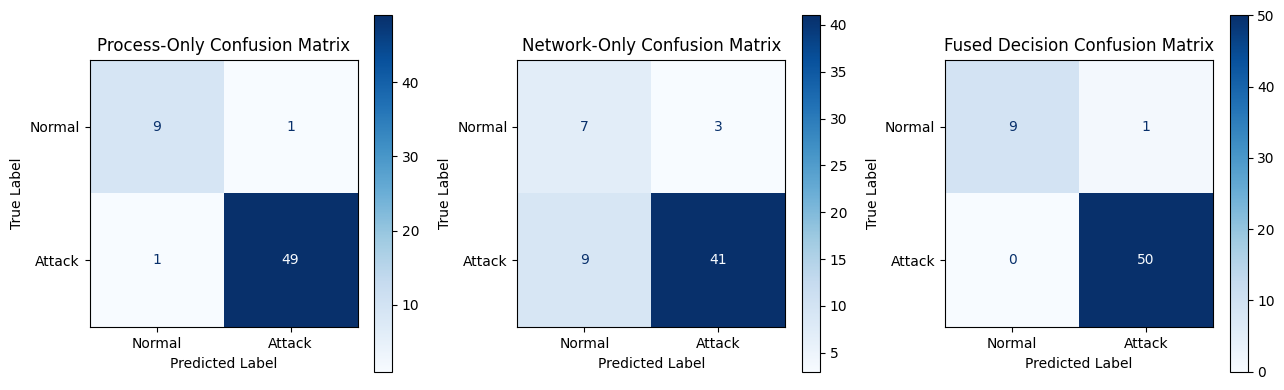

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define binary ground truth: 0 = normal, 1 = attack (any label other than 0)
df_combined['true_binary'] = df_combined['Process_Ground_Truth'].apply(lambda x: 0 if x == 0 else 1)

# Binary predictions for each method
df_combined['process_binary'] = df_combined['Process_Predicted_Label'].apply(lambda x: 0 if x == 0 else 1)
df_combined['network_binary'] = df_combined['Network_Predicted_Label'].apply(lambda x: 0 if x == 0 else 1)
df_combined['fused_binary'] = df_combined['final_fused_label'].apply(lambda x: 0 if x == 0 else 1)

# Compute confusion matrices
cm_process = confusion_matrix(df_combined['true_binary'], df_combined['process_binary'])
cm_network = confusion_matrix(df_combined['true_binary'], df_combined['network_binary'])
cm_fused   = confusion_matrix(df_combined['true_binary'], df_combined['fused_binary'])

# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ['Process-Only', 'Network-Only', 'Fused Decision']
cms = [cm_process, cm_network, cm_fused]

for ax, cm, title in zip(axes, cms, titles):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(ax=ax, values_format='d', cmap='Blues')
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

**Fusion logic corrected predictions originally misclassified by the process model alone — specifically by leveraging network anomaly scores.**

In [59]:
from sklearn.metrics import classification_report

print("Process-Only Report:\n", classification_report(df_combined['true_binary'], df_combined['process_binary']))
print("Network-Only Report:\n", classification_report(df_combined['true_binary'], df_combined['network_binary']))
print("Fused Decision Report:\n", classification_report(df_combined['true_binary'], df_combined['fused_binary']))

Process-Only Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.98      0.98      0.98        50

    accuracy                           0.97        60
   macro avg       0.94      0.94      0.94        60
weighted avg       0.97      0.97      0.97        60

Network-Only Report:
               precision    recall  f1-score   support

           0       0.44      0.70      0.54        10
           1       0.93      0.82      0.87        50

    accuracy                           0.80        60
   macro avg       0.68      0.76      0.71        60
weighted avg       0.85      0.80      0.82        60

Fused Decision Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.98      1.00      0.99        50

    accuracy                           0.98        60
   macro avg       0.99      0.95      0.97        60
weight

# Dashboard for Reporting

The dashboard is to be adjusted for instances over time, where x-axis will be the timeline.

In [64]:
reason_map = {
    'confident_threat': 'High confidence — Threat detected',
    'confident_normal': 'High confidence — Normal behavior',
    'conflict_process_higher': 'Disagreement — Process more confident',
    'conflict_network_higher': 'Disagreement — Network more confident',
    'error_attack_score': 'Error extracting process class scores',
}

df_combined['reason_description'] = df_combined['decision_reason'].map(reason_map)

In [65]:
display(df_combined[['instance', 'final_fused_label', 'reason_description']])

,instance,final_fused_label,reason_description
0,1,0,High confidence — Normal behavior
1,2,0,High confidence — Normal behavior
2,3,0,High confidence — Normal behavior
3,4,2,High confidence — Threat detected
4,5,0,High confidence — Normal behavior
5,6,0,High confidence — Normal behavior
6,7,0,High confidence — Normal behavior
7,8,0,High confidence — Normal behavior
8,9,0,High confidence — Normal behavior
9,10,0,High confidence — Normal behavior


In [69]:
import plotly.express as px

fig = px.scatter(
    df_combined,
    x='instance',
    y='process_score',
    color='decision_reason',
    hover_data=['final_fused_label', 'reason_description'],
    title='Process Confidence with Fusion Reason'
)
fig.show()

The end